In [5]:
# A "variable" is a name pinned to a value. The = sign means "store this under that name".
price = 250000
city = "Ames"
sizes = [1200, 1500, 2100]        # a list: several values in order, in square brackets

# print() displays something. The f"..." lets you drop variables inside text using { }.
print(f"A house in {city} sold for ${price:,}")
print(f"The list has {len(sizes)} entries and the first one is {sizes[0]}")

A house in Ames sold for $250,000
The list has 3 entries and the first one is 1200


In [6]:
# A "function" is a saved recipe. def creates one. It takes inputs and returns an output.
def price_per_sqft(total_price, square_feet):
    return total_price / square_feet          # / is division

# "Calling" the function = running the recipe with real inputs.
result = price_per_sqft(250000, 1500)
print(f"${result:.2f} per square foot")       # :.2f means "show 2 decimal places"

$166.67 per square foot


In [7]:
# You don't write machine learning from scratch. You import libraries other people built.
import pandas as pd                    # pandas = tables of data. "pd" is its nickname.
import numpy as np                     # numpy  = fast maths on lists of numbers
import matplotlib.pyplot as plt        # matplotlib = charts

print("pandas version:", pd.__version__)
print("numpy  version:", np.__version__)

pandas version: 3.0.5
numpy  version: 2.5.2


In [8]:
# A DataFrame is a spreadsheet living inside Python. Rows and named columns.
demo = pd.DataFrame({
    "size":  [1200, 1500, 2100, 900],
    "price": [180000, 215000, 310000, 140000],
})
demo                                    # the last line of a cell displays itself

,size,price
0,1200,180000
1,1500,215000
2,2100,310000
3,900,140000


In [9]:
# Grabbing parts of a table — the three moves you need:
print("One column:")
print(demo["size"])                     # square brackets + the column name in quotes

print("\nTwo columns (note the DOUBLE brackets):")
print(demo[["size", "price"]])          # a LIST of names inside the brackets

print("\nOnly the big houses:")
print(demo[demo["size"] > 1400])        # a condition inside the brackets = filter rows

One column:
0    1200
1    1500
2    2100
3     900
Name: size, dtype: int64

Two columns (note the DOUBLE brackets):
   size   price
0  1200  180000
1  1500  215000
2  2100  310000
3   900  140000

Only the big houses:
   size   price
1  1500  215000
2  2100  310000


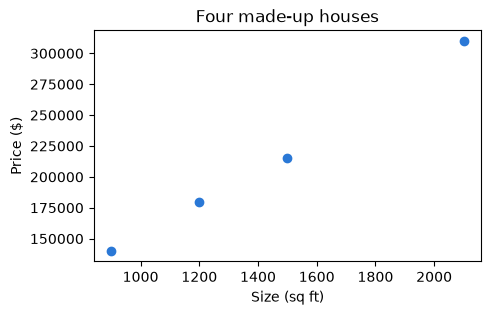

In [10]:
# One chart, so the plotting syntax isn't a surprise later.
plt.figure(figsize=(5, 3))                                  # make a canvas 5x3 inches
plt.scatter(demo["size"], demo["price"], color="#2a78d6")   # x values, y values, colour
plt.xlabel("Size (sq ft)")                                  # label the horizontal axis
plt.ylabel("Price ($)")                                     # label the vertical axis
plt.title("Four made-up houses")
plt.show()                                                  # draw it

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Chart styling, set once so every chart in the notebook matches.
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.edgecolor": "#8a8985", "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e",
    "figure.facecolor": "white", "axes.facecolor": "white",
})
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
VIOLET, RED, GREEN, PINK = "#4a3aa7", "#e34948", "#008300", "#e87ba4"

ames = pd.read_csv("data/ames.csv")     # read the file into a DataFrame

print(f"Rows (houses):   {ames.shape[0]:,}")
print(f"Columns (facts): {ames.shape[1]}")

Rows (houses):   2,930
Columns (facts): 82


In [12]:
# Look at a few real rows, a few interesting columns.
ames[["Gr Liv Area", "Year Built", "Overall Qual", "Neighborhood", "SalePrice"]].head()

,Gr Liv Area,Year Built,Overall Qual,Neighborhood,SalePrice
0,1656,1960,6,NAmes,215000
1,896,1961,5,NAmes,105000
2,1329,1958,6,NAmes,172000
3,2110,1968,7,NAmes,244000
4,1629,1997,5,Gilbert,189900


In [13]:
# What do prices actually look like?
print(ames["SalePrice"].describe().round(0))

count      2930.0
mean     180796.0
std       79887.0
min       12789.0
25%      129500.0
50%      160000.0
75%      213500.0
max      755000.0
Name: SalePrice, dtype: float64


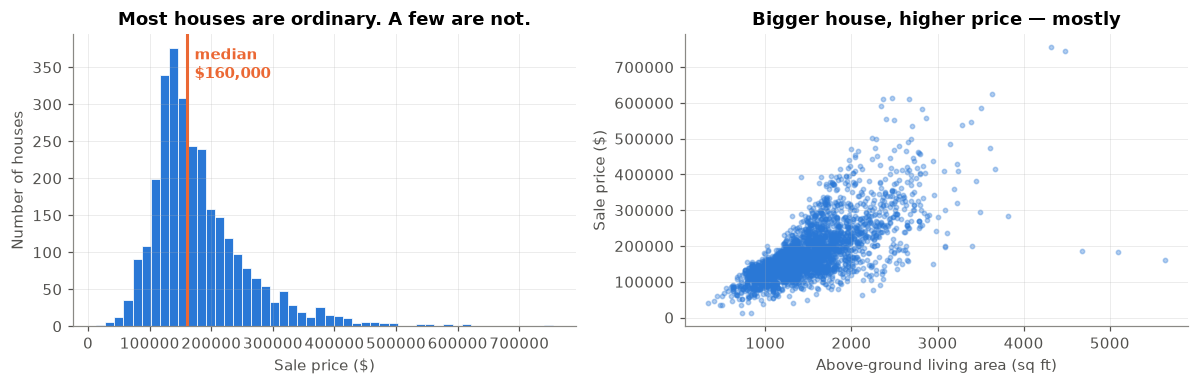

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].hist(ames["SalePrice"], bins=50, color=BLUE, edgecolor="white", linewidth=0.5)
axes[0].axvline(ames["SalePrice"].median(), color=ORANGE, linewidth=2)
axes[0].text(ames["SalePrice"].median()*1.08, axes[0].get_ylim()[1]*0.85,
             f"median\n${ames['SalePrice'].median():,.0f}", color=ORANGE, fontweight="bold")
axes[0].set_xlabel("Sale price ($)"); axes[0].set_ylabel("Number of houses")
axes[0].set_title("Most houses are ordinary. A few are not.")

axes[1].scatter(ames["Gr Liv Area"], ames["SalePrice"], s=8, alpha=0.35, color=BLUE)
axes[1].set_xlabel("Above-ground living area (sq ft)"); axes[1].set_ylabel("Sale price ($)")
axes[1].set_title("Bigger house, higher price — mostly")

plt.tight_layout(); plt.show()

In [15]:
# Dean De Cock, who published this dataset, explicitly recommends removing these.
outliers = ames[ames["Gr Liv Area"] > 4000]
print(outliers[["Gr Liv Area", "Overall Qual", "Sale Condition", "SalePrice"]])

      Gr Liv Area  Overall Qual Sale Condition  SalePrice
1498         5642            10        Partial     160000
1760         4476            10        Abnorml     745000
1767         4316            10         Normal     755000
2180         5095            10        Partial     183850
2181         4676            10        Partial     184750


In [16]:
houses = ames[ames["Gr Liv Area"] <= 4000].copy()   # .copy() = work on a fresh copy
print(f"Before: {len(ames):,} houses")
print(f"After:  {len(houses):,} houses  ({len(ames) - len(houses)} removed)")

Before: 2,930 houses
After:  2,925 houses  (5 removed)


In [17]:
from sklearn.linear_model import LinearRegression

# X = what the model sees (features). Double brackets = a table, even for one column.
# y = what the model must predict (the target). Single brackets = one column.
X_simple = houses[["Gr Liv Area"]]
y = houses["SalePrice"]

model_1 = LinearRegression()      # 1. create an empty, untrained model
model_1.fit(X_simple, y)          # 2. show it the data — this is the "learning"

slope = model_1.coef_[0]
intercept = model_1.intercept_
print(f"Slope     (m): ${slope:,.2f} per extra square foot")
print(f"Intercept (b): ${intercept:,.0f}")

Slope     (m): $116.23 per extra square foot
Intercept (b): $6,773


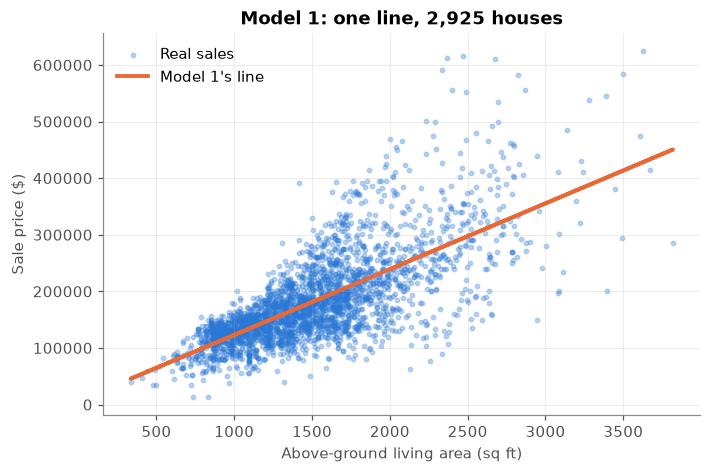

In [18]:
# Ask the trained model for predictions, then draw its line over the real dots.
pred_line = model_1.predict(X_simple)

plt.figure(figsize=(7, 4.5))
plt.scatter(houses["Gr Liv Area"], y, s=8, alpha=0.3, color=BLUE, label="Real sales")
plt.plot(houses["Gr Liv Area"], pred_line, color=ORANGE, linewidth=2.5, label="Model 1's line")
plt.xlabel("Above-ground living area (sq ft)"); plt.ylabel("Sale price ($)")
plt.title("Model 1: one line, 2,925 houses")
plt.legend(frameon=False)
plt.show()

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y,
    test_size=0.2,        # 20% goes in the locked drawer
    random_state=42       # a fixed "seed" so the split is identical every run
)

print(f"Training set: {len(X_train):,} houses  (the model studies these)")
print(f"Test set:     {len(X_test):,} houses  (the model never sees these until scoring)")

Training set: 2,340 houses  (the model studies these)
Test set:     585 houses  (the model never sees these until scoring)


In [21]:
# Retrain on the training half only, then predict the locked-away test half.
model_1 = LinearRegression()
model_1.fit(X_train, y_train)
y_pred = model_1.predict(X_test)

# Show the first five predictions against reality.
comparison = pd.DataFrame({
    "Actual": y_test.values[:5],
    "Predicted": y_pred[:5].round(0),
})
comparison["Error"] = comparison["Predicted"] - comparison["Actual"]
comparison

,Actual,Predicted,Error
0,143000,175784.0,32784.0
1,437154,319196.0,-117958.0
2,205950,199348.0,-6602.0
3,235000,152785.0,-82215.0
4,138000,226294.0,88294.0


In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f"MAE   {mae:>14,.0f}   average miss, in dollars")
print(f"MSE   {mse:>14,.0f}   average SQUARED miss, in dollars-squared")
print(f"RMSE  {rmse:>14,.0f}   square root of MSE, back in dollars")
print(f"R²    {r2:>14.3f}   share of price variation explained (0 to 1)")

MAE           39,604   average miss, in dollars
MSE    3,424,542,702   average SQUARED miss, in dollars-squared
RMSE          58,520   square root of MSE, back in dollars
R²             0.518   share of price variation explained (0 to 1)


In [23]:
# A results table we'll add one row to after every model.
results = []

def score_model(name, y_true, y_hat, note="", key=""):
    """Score a model, print it, and remember it for the final comparison."""
    row = {
        "Model": name,
        "key": key,
        "MAE ($)": mean_absolute_error(y_true, y_hat),
        "RMSE ($)": np.sqrt(mean_squared_error(y_true, y_hat)),
        "R²": r2_score(y_true, y_hat),
        "Note": note,
    }
    results.append(row)
    print(f"{name:<28} MAE ${row['MAE ($)']:>8,.0f}   RMSE ${row['RMSE ($)']:>8,.0f}   R² {row['R²']:.3f}")

score_model("1. Simple Linear (1 feature)", y_test, y_pred, "Size only", "01_simple_linear")

1. Simple Linear (1 feature) MAE $  39,604   RMSE $  58,520   R² 0.518


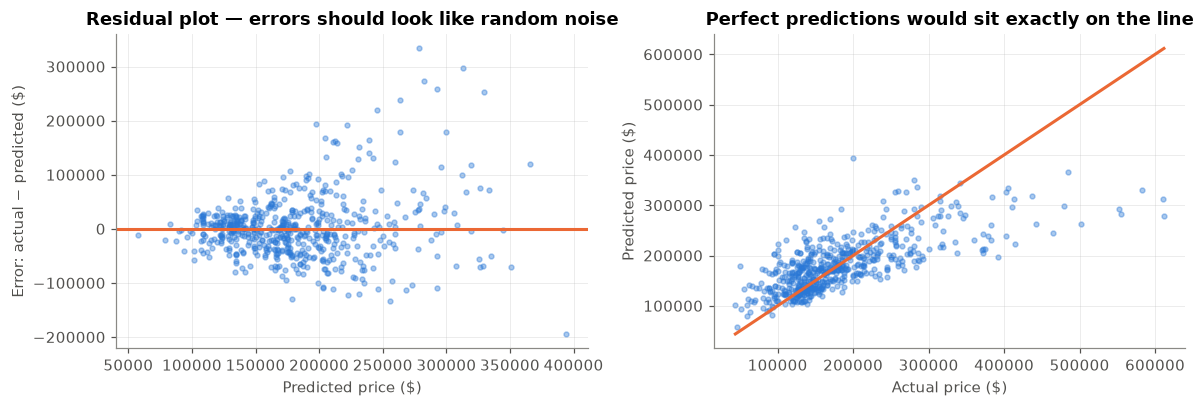

In [24]:
# One more diagnostic that no metric can replace: look at the errors.
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].scatter(y_pred, residuals, s=10, alpha=0.4, color=BLUE)
axes[0].axhline(0, color=ORANGE, linewidth=2)
axes[0].set_xlabel("Predicted price ($)"); axes[0].set_ylabel("Error: actual − predicted ($)")
axes[0].set_title("Residual plot — errors should look like random noise")

axes[1].scatter(y_test, y_pred, s=10, alpha=0.4, color=BLUE)
lims = [y_test.min(), y_test.max()]
axes[1].plot(lims, lims, color=ORANGE, linewidth=2)
axes[1].set_xlabel("Actual price ($)"); axes[1].set_ylabel("Predicted price ($)")
axes[1].set_title("Perfect predictions would sit exactly on the line")

plt.tight_layout(); plt.show()

In [25]:
# Pick the features. These are the facts a competent estate agent would actually ask about.
numeric_features = [
    "Gr Liv Area",      # above-ground living area, sq ft
    "Total Bsmt SF",    # basement area, sq ft
    "1st Flr SF",       # first floor area, sq ft
    "Lot Area",         # plot size, sq ft
    "Overall Qual",     # 1-10 material & finish rating
    "Overall Cond",     # 1-10 condition rating
    "Year Built",
    "Year Remod/Add",   # year of last remodel
    "Garage Cars",      # capacity in cars
    "Garage Area",
    "Full Bath",
    "Half Bath",
    "TotRms AbvGrd",    # total rooms above ground
    "Fireplaces",
    "Mas Vnr Area",     # masonry veneer area, sq ft
    "Wood Deck SF",
    "Open Porch SF",
]

categorical_features = [
    "Neighborhood",     # 28 districts of Ames
    "House Style",      # 1-storey, 2-storey, split-level...
    "Bldg Type",        # detached, townhouse, duplex...
    "Exter Qual",       # exterior material quality
    "Kitchen Qual",
    "Bsmt Qual",
    "Heating QC",
    "Central Air",      # Y / N
    "Foundation",
    "Garage Type",
]

all_features = numeric_features + categorical_features    # + joins two lists
print(f"{len(numeric_features)} numeric + {len(categorical_features)} categorical "
      f"= {len(all_features)} features")

17 numeric + 10 categorical = 27 features


In [26]:
# PROBLEM 1: missing values. Linear regression crashes on empty cells.
X = houses[all_features]
missing = X.isna().sum()
print(missing[missing > 0].sort_values(ascending=False))

Garage Type      157
Bsmt Qual         80
Mas Vnr Area      23
Total Bsmt SF      1
Garage Cars        1
Garage Area        1
dtype: int64


In [27]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Recipe for the number columns: fill holes with the median, then rescale.
numeric_pipe = Pipeline([
    ("fill",  SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

# Recipe for the word columns: fill holes with "Missing", then one-hot encode.
categorical_pipe = Pipeline([
    ("fill",   SimpleImputer(strategy="constant", fill_value="Missing")),
    ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# Apply each recipe to the right columns.
preprocessor = ColumnTransformer([
    ("num", numeric_pipe,     numeric_features),
    ("cat", categorical_pipe, categorical_features),
])

print("Preprocessor built. It will be reused, unchanged, by every model from here on.")

Preprocessor built. It will be reused, unchanged, by every model from here on.


In [28]:
# Re-split, this time with all 27 features.
X = houses[all_features]
y = houses["SalePrice"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Glue the preprocessor to the model so they train and predict as one object.
model_2 = Pipeline([
    ("prep",  preprocessor),
    ("model", LinearRegression()),
])

model_2.fit(X_train, y_train)
y_pred_2 = model_2.predict(X_test)

score_model("2. Multiple Linear (27 feat)", y_test, y_pred_2, "All features", "02_multiple_linear")

2. Multiple Linear (27 feat) MAE $  15,392   RMSE $  23,701   R² 0.921


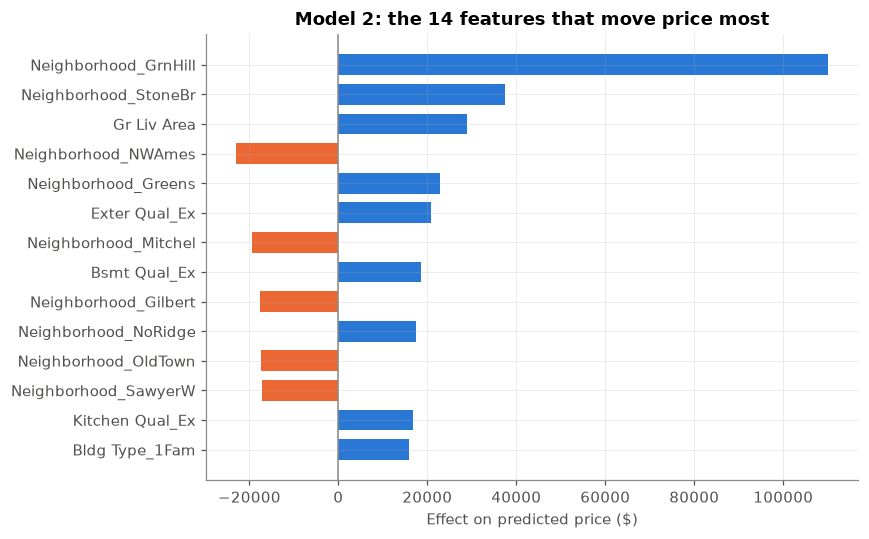

In [29]:
# What did it learn? Pull out the coefficients and read the biggest ones.
feature_names = model_2.named_steps["prep"].get_feature_names_out()
coefs = pd.Series(model_2.named_steps["model"].coef_, index=feature_names)

top = coefs.reindex(coefs.abs().sort_values(ascending=False).index)[:14][::-1]

plt.figure(figsize=(8, 5))
colors = [ORANGE if v < 0 else BLUE for v in top.values]
plt.barh(range(len(top)), top.values, color=colors, height=0.7)
plt.yticks(range(len(top)), [n.split("__")[-1] for n in top.index])
plt.axvline(0, color="#8a8985", linewidth=1)
plt.xlabel("Effect on predicted price ($)")
plt.title("Model 2: the 14 features that move price most")
plt.tight_layout(); plt.show()

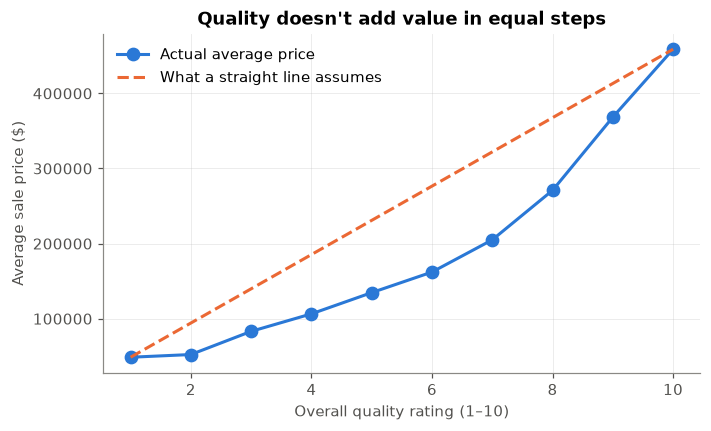

In [30]:
# First, is there actually a curve? Look at average price per quality rating.
by_qual = houses.groupby("Overall Qual")["SalePrice"].mean()

plt.figure(figsize=(7, 4))
plt.plot(by_qual.index, by_qual.values, marker="o", markersize=8,
         color=BLUE, linewidth=2, label="Actual average price")
plt.plot([by_qual.index.min(), by_qual.index.max()],
         [by_qual.values.min(), by_qual.values.max()],
         color=ORANGE, linewidth=2, linestyle="--", label="What a straight line assumes")
plt.xlabel("Overall quality rating (1–10)"); plt.ylabel("Average sale price ($)")
plt.title("Quality doesn't add value in equal steps")
plt.legend(frameon=False)
plt.show()

In [31]:
from sklearn.preprocessing import PolynomialFeatures

# Same preprocessor, but the numeric branch now also generates squares and products.
poly_numeric_pipe = Pipeline([
    ("fill",  SimpleImputer(strategy="median")),
    ("poly",  PolynomialFeatures(degree=2, include_bias=False)),
    ("scale", StandardScaler()),
])

poly_preprocessor = ColumnTransformer([
    ("num", poly_numeric_pipe,  numeric_features),
    ("cat", categorical_pipe,   categorical_features),
])

model_3 = Pipeline([("prep", poly_preprocessor), ("model", LinearRegression())])
model_3.fit(X_train, y_train)
y_pred_3 = model_3.predict(X_test)

n_before = len(numeric_features)
n_after = model_3.named_steps["prep"].transform(X_train.head(1)).shape[1]
print(f"Columns going in:  {len(all_features)}")
print(f"Columns after expansion: {n_after}\n")

score_model("3. Polynomial (degree 2)", y_test, y_pred_3, "Squares & interactions", "03_polynomial")

Columns going in:  27
Columns after expansion: 245

3. Polynomial (degree 2)     MAE $  14,422   RMSE $  24,002   R² 0.919


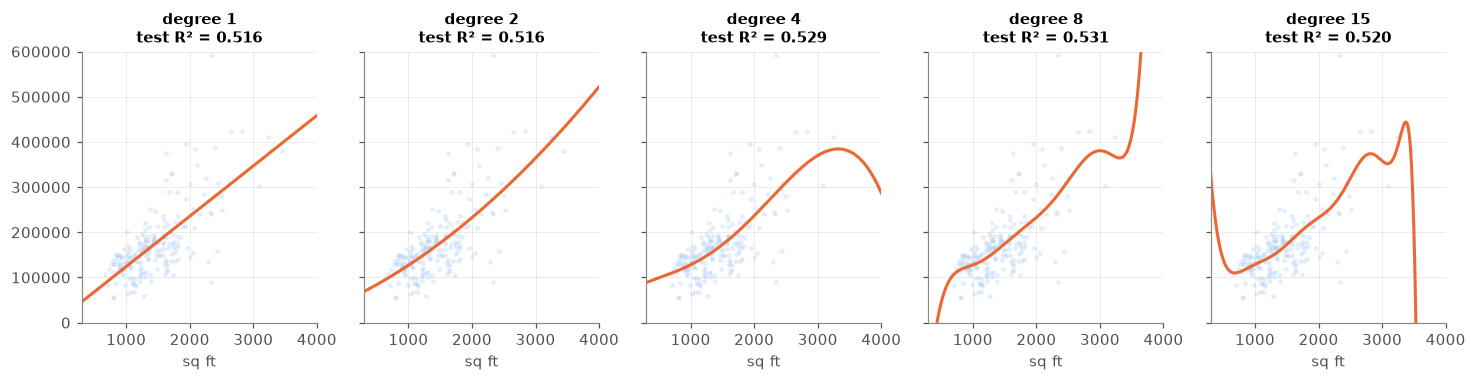

In [32]:
# The overfitting demo. One feature, five increasingly flexible curves.
from sklearn.preprocessing import PolynomialFeatures

x_one = houses[["Gr Liv Area"]]
xtr_full, xte, ytr_full, yte = train_test_split(x_one, y, test_size=0.2, random_state=42)

# Deliberately train on only 200 houses. Overfitting is a data-scarcity disease:
# with 2,000 examples even a silly model behaves; with 200 it starts to run riot.
xtr = xtr_full.sample(200, random_state=7)
ytr = ytr_full.loc[xtr.index]

grid = pd.DataFrame({"Gr Liv Area": np.linspace(300, 4000, 400)})
degrees = [1, 2, 4, 8, 15]
train_scores, test_scores = [], []

fig, axes = plt.subplots(1, 5, figsize=(16, 3.2), sharey=True)
for ax, d in zip(axes, degrees):
    m = Pipeline([("poly", PolynomialFeatures(degree=d, include_bias=False)),
                  ("scale", StandardScaler()),
                  ("lin", LinearRegression())])
    m.fit(xtr, ytr)
    train_scores.append(r2_score(ytr, m.predict(xtr)))
    test_scores.append(r2_score(yte, m.predict(xte)))
    ax.scatter(xtr["Gr Liv Area"], ytr, s=5, alpha=0.2, color="#9ec5f4")
    ax.plot(grid["Gr Liv Area"], m.predict(grid), color=ORANGE, linewidth=2)
    ax.set_ylim(0, 600000); ax.set_xlim(300, 4000)
    ax.set_title(f"degree {d}\ntest R² = {test_scores[-1]:.3f}", fontsize=10)
    ax.set_xlabel("sq ft")

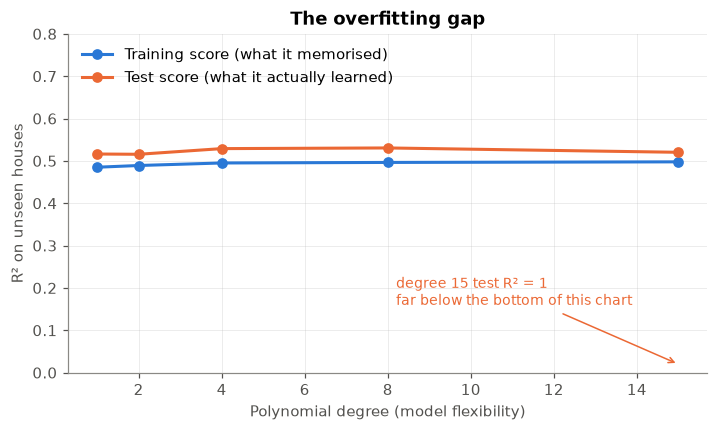

degree  1:  train R²  0.485   test R²          0.516
degree  2:  train R²  0.489   test R²          0.516
degree  4:  train R²  0.495   test R²          0.529
degree  8:  train R²  0.496   test R²          0.531
degree 15:  train R²  0.498   test R²          0.520


In [33]:
plt.figure(figsize=(7.5, 4))
plt.plot(degrees, train_scores, marker="o", color=BLUE, linewidth=2,
         label="Training score (what it memorised)")
plt.plot(degrees, test_scores, marker="o", color=ORANGE, linewidth=2,
         label="Test score (what it actually learned)")
plt.ylim(0, 0.8)                       # degree 15's test score is far below zero
plt.annotate(f"degree 15 test R² = {test_scores[-1]:,.0f}\nfar below the bottom of this chart",
             xy=(15, 0.02), xytext=(8.2, 0.16), color=ORANGE, fontsize=9,
             arrowprops=dict(arrowstyle="->", color=ORANGE))
plt.xlabel("Polynomial degree (model flexibility)"); plt.ylabel("R² on unseen houses")
plt.title("The overfitting gap")
plt.legend(frameon=False, loc="upper left")
plt.show()

for d, tr, te in zip(degrees, train_scores, test_scores):
    print(f"degree {d:>2}:  train R² {tr:>6.3f}   test R² {te:>14,.3f}")

In [34]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

alphas = np.logspace(-2, 4, 60)     # 60 candidate values from 0.01 to 10,000

# Ridge, on the polynomial feature set — that's where overfitting was worst.
model_4 = Pipeline([
    ("prep",  poly_preprocessor),
    ("model", RidgeCV(alphas=alphas, cv=5)),
])
model_4.fit(X_train, y_train)
y_pred_4 = model_4.predict(X_test)

print(f"Ridge picked alpha = {model_4.named_steps['model'].alpha_:,.2f}\n")
score_model("4. Ridge (L2)", y_test, y_pred_4, "Polynomial + shrinkage", "04_ridge")

Ridge picked alpha = 45.82

4. Ridge (L2)                MAE $  13,829   RMSE $  22,230   R² 0.930


In [35]:
# Lasso is solved by iterative approximation, and on 245 correlated polynomial features
# it keeps nudging coefficients long after the answer has stopped meaningfully changing.
# It prints a warning every time. We silence that ONE warning to keep the output readable.
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

model_5 = Pipeline([
    ("prep",  poly_preprocessor),
    ("model", LassoCV(alphas=alphas, cv=5, max_iter=20000, random_state=42)),
])
model_5.fit(X_train, y_train)
y_pred_5 = model_5.predict(X_test)

lasso_coefs = model_5.named_steps["model"].coef_
n_total = len(lasso_coefs)
n_zero = int((lasso_coefs == 0).sum())

print(f"Lasso picked alpha = {model_5.named_steps['model'].alpha_:,.2f}")
print(f"Features available: {n_total}")
print(f"Features deleted (coefficient set to exactly 0): {n_zero}  ({n_zero/n_total:.0%})")
print(f"Features kept: {n_total - n_zero}\n")

score_model("5. Lasso (L1)", y_test, y_pred_5, f"Kept {n_total-n_zero}/{n_total} features", "05_lasso")

Lasso picked alpha = 116.90
Features available: 245
Features deleted (coefficient set to exactly 0): 162  (66%)
Features kept: 83

5. Lasso (L1)                MAE $  13,905   RMSE $  21,661   R² 0.934


In [36]:
# Elastic Net — searches l1_ratio as well as alpha.
model_6 = Pipeline([
    ("prep",  poly_preprocessor),
    ("model", ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
                           alphas=alphas, cv=5, max_iter=20000, random_state=42)),
])
model_6.fit(X_train, y_train)
y_pred_6 = model_6.predict(X_test)

en = model_6.named_steps["model"]
print(f"Elastic Net picked alpha = {en.alpha_:,.2f}, l1_ratio = {en.l1_ratio_}")
print(f"   (l1_ratio 0 = pure Ridge, 1 = pure Lasso)\n")
score_model("6. Elastic Net (L1+L2)", y_test, y_pred_6, f"l1_ratio={en.l1_ratio_}", "06_elastic_net")

Elastic Net picked alpha = 116.90, l1_ratio = 1.0
   (l1_ratio 0 = pure Ridge, 1 = pure Lasso)

6. Elastic Net (L1+L2)       MAE $  13,905   RMSE $  21,661   R² 0.934


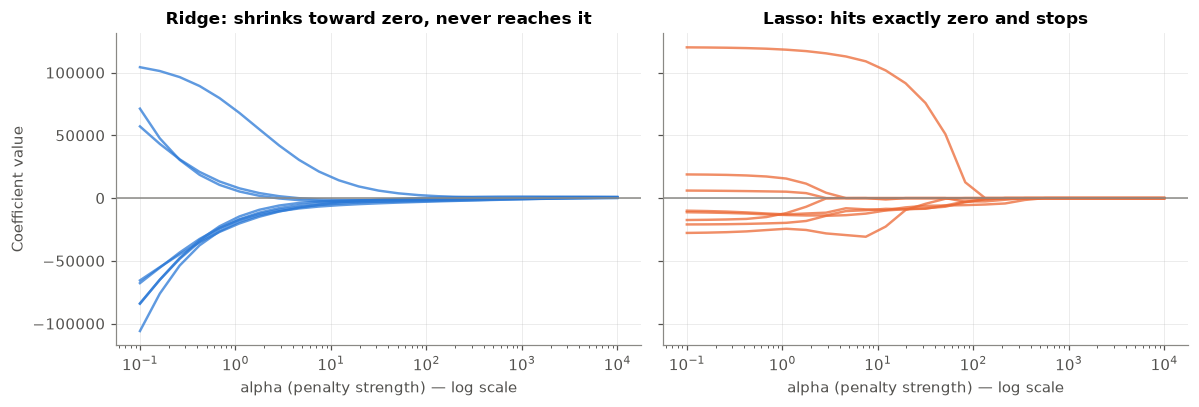

In [37]:
# See the shrinkage happen. Same feature, ten alphas, three penalties.
from sklearn.linear_model import Ridge, Lasso

test_alphas = np.logspace(-1, 4, 25)
Xtr_p = poly_preprocessor.fit_transform(X_train)
ridge_paths, lasso_paths = [], []
for a in test_alphas:
    ridge_paths.append(Ridge(alpha=a).fit(Xtr_p, y_train).coef_)
    lasso_paths.append(Lasso(alpha=a, max_iter=5000).fit(Xtr_p, y_train).coef_)
ridge_paths, lasso_paths = np.array(ridge_paths), np.array(lasso_paths)

pick = np.argsort(np.abs(ridge_paths[0]))[-8:]      # 8 initially-loudest features

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for i in pick:
    axes[0].plot(test_alphas, ridge_paths[:, i], color=BLUE, alpha=0.75, linewidth=1.6)
    axes[1].plot(test_alphas, lasso_paths[:, i], color=ORANGE, alpha=0.75, linewidth=1.6)
for ax, t in zip(axes, ["Ridge: shrinks toward zero, never reaches it",
                        "Lasso: hits exactly zero and stops"]):
    ax.set_xscale("log"); ax.axhline(0, color="#8a8985", linewidth=1)
    ax.set_xlabel("alpha (penalty strength) — log scale"); ax.set_title(t, fontsize=11)
axes[0].set_ylabel("Coefficient value")
plt.tight_layout(); plt.show()

In [39]:
from sklearn.svm import SVR
from sklearn.compose import TransformedTargetRegressor

# SVR needs the TARGET scaled too, not just the features. See the note below.
svr_inner = SVR(kernel="rbf", C=10.0, epsilon=0.1, gamma="scale")

model_7 = Pipeline([
    ("prep",  preprocessor),
    ("model", TransformedTargetRegressor(regressor=svr_inner, transformer=StandardScaler())),
])
model_7.fit(X_train, y_train)
y_pred_7 = model_7.predict(X_test)

score_model("7. SVR (RBF kernel)", y_test, y_pred_7, "C=10, epsilon=0.1", "07_svr")


7. SVR (RBF kernel)          MAE $  15,396   RMSE $  22,674   R² 0.928


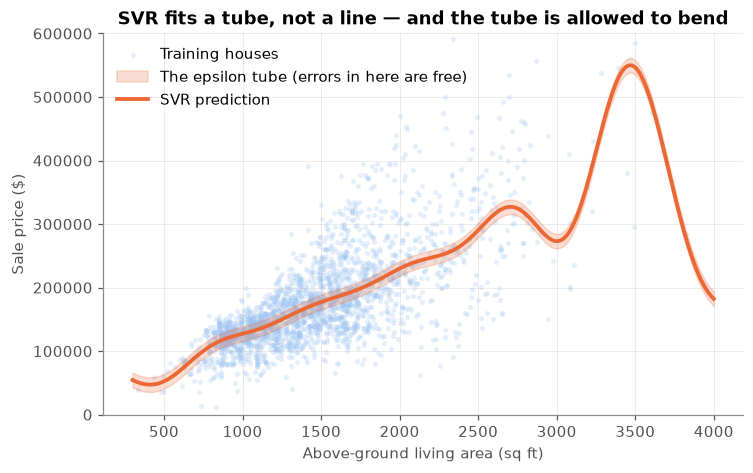

In [40]:
# What the tube actually looks like, on one feature so it's visible.
svr_demo = Pipeline([("scale", StandardScaler()),
                     ("m", TransformedTargetRegressor(regressor=SVR(kernel="rbf", C=50, epsilon=0.15),
                                                      transformer=StandardScaler()))])
svr_demo.fit(xtr_full, ytr_full)   # the FULL one-feature training set, not the 200-house sample
gx = pd.DataFrame({"Gr Liv Area": np.linspace(300, 4000, 300)})
gy = svr_demo.predict(gx)
band = 0.15 * ytr_full.std()

plt.figure(figsize=(7.5, 4.5))
plt.scatter(xtr_full["Gr Liv Area"], ytr_full, s=6, alpha=0.2, color="#9ec5f4", label="Training houses")
plt.fill_between(gx["Gr Liv Area"], gy - band, gy + band, color=ORANGE, alpha=0.22,
                 label="The epsilon tube (errors in here are free)")
plt.plot(gx["Gr Liv Area"], gy, color=ORANGE, linewidth=2.5, label="SVR prediction")
plt.ylim(0, 600000)
plt.xlabel("Above-ground living area (sq ft)"); plt.ylabel("Sale price ($)")
plt.title("SVR fits a tube, not a line — and the tube is allowed to bend")
plt.legend(frameon=False, loc="upper left")
plt.show()

In [41]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

# First: what happens with NO limit on depth?
unlimited = Pipeline([("prep", preprocessor),
                      ("model", DecisionTreeRegressor(random_state=42))])
unlimited.fit(X_train, y_train)

print(f"Tree depth: {unlimited.named_steps['model'].get_depth()} levels")
print(f"Leaf groups: {unlimited.named_steps['model'].get_n_leaves():,}")
print(f"Training R²: {r2_score(y_train, unlimited.predict(X_train)):.4f}   <-- looks perfect")
print(f"Test R²:     {r2_score(y_test,  unlimited.predict(X_test)):.4f}   <-- reality")

Tree depth: 25 levels
Leaf groups: 2,248
Training R²: 1.0000   <-- looks perfect
Test R²:     0.8232   <-- reality


In [42]:
# Search for a sensible depth using cross-validation on the TRAINING set only.
from sklearn.model_selection import GridSearchCV

tree_search = GridSearchCV(
    Pipeline([("prep", preprocessor), ("model", DecisionTreeRegressor(random_state=42))]),
    param_grid={
        "model__max_depth":         [4, 6, 8, 10, 12, None],
        "model__min_samples_leaf":  [1, 5, 10, 20],
    },
    cv=5, scoring="neg_mean_absolute_error", n_jobs=-1,
)
tree_search.fit(X_train, y_train)

print("Best settings found:", tree_search.best_params_)
model_8 = tree_search.best_estimator_
y_pred_8 = model_8.predict(X_test)

score_model("8. Decision Tree (pruned)", y_test, y_pred_8,
            f"depth={tree_search.best_params_['model__max_depth']}", "08_decision_tree")

Best settings found: {'model__max_depth': 10, 'model__min_samples_leaf': 20}
8. Decision Tree (pruned)    MAE $  19,285   RMSE $  28,036   R² 0.889


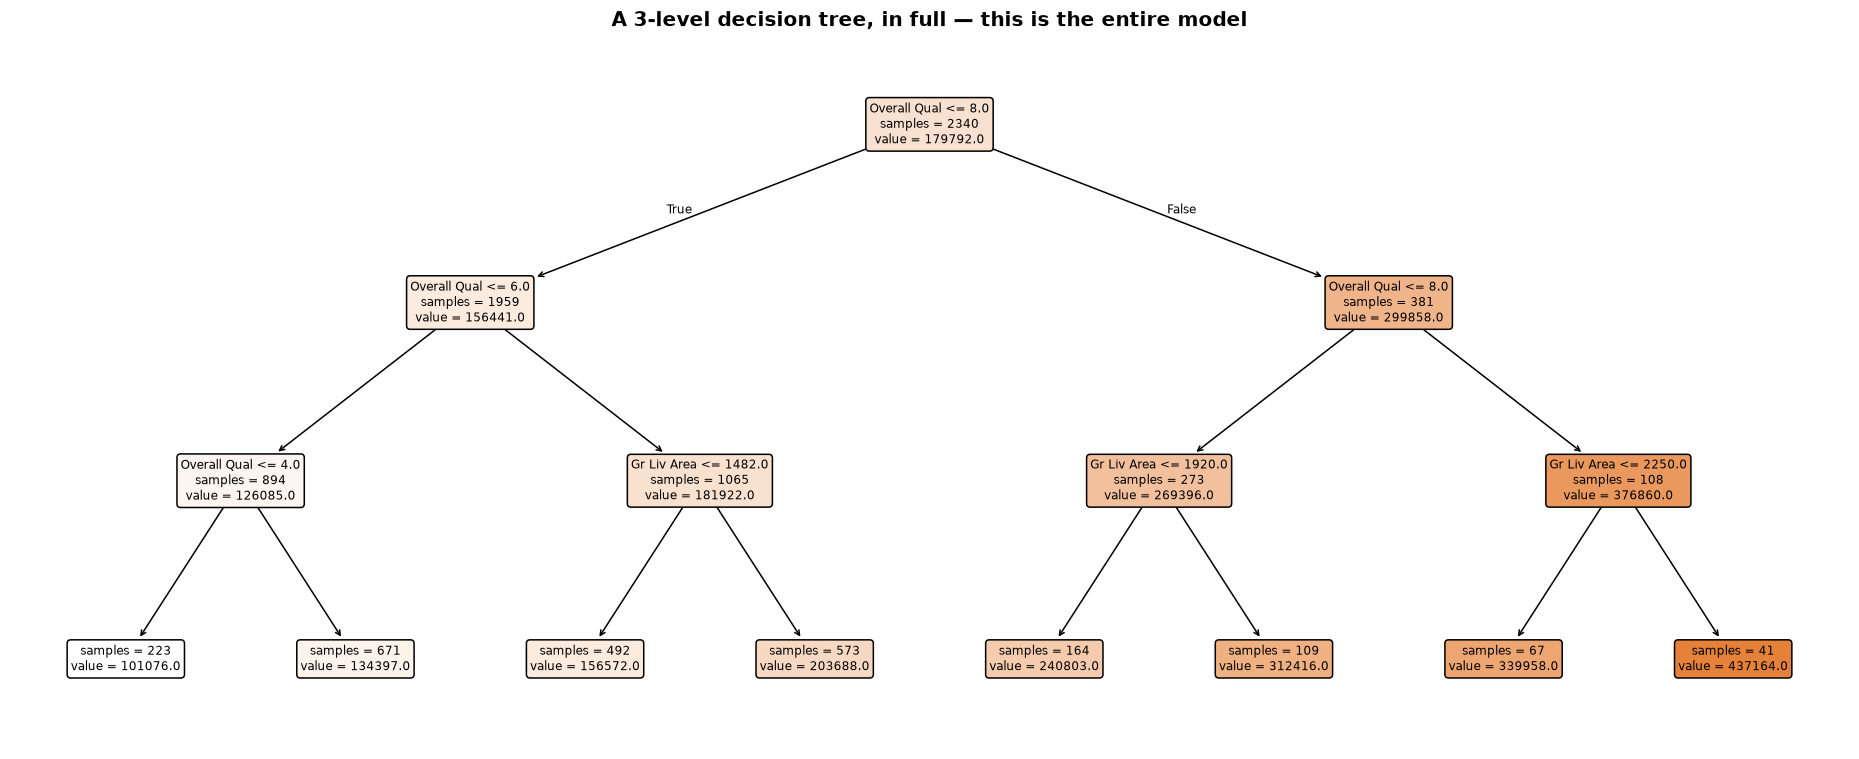

In [43]:
# Draw a small tree so you can read the actual logic.
readable = ["Overall Qual", "Gr Liv Area", "Year Built", "Total Bsmt SF", "Garage Cars"]
small = DecisionTreeRegressor(max_depth=3, min_samples_leaf=20, random_state=42)
small.fit(X_train[readable].fillna(0), y_train)

plt.figure(figsize=(17, 7))
plot_tree(small, feature_names=readable, filled=True, rounded=True,
          fontsize=8, precision=0, impurity=False)
plt.title("A 3-level decision tree, in full — this is the entire model", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

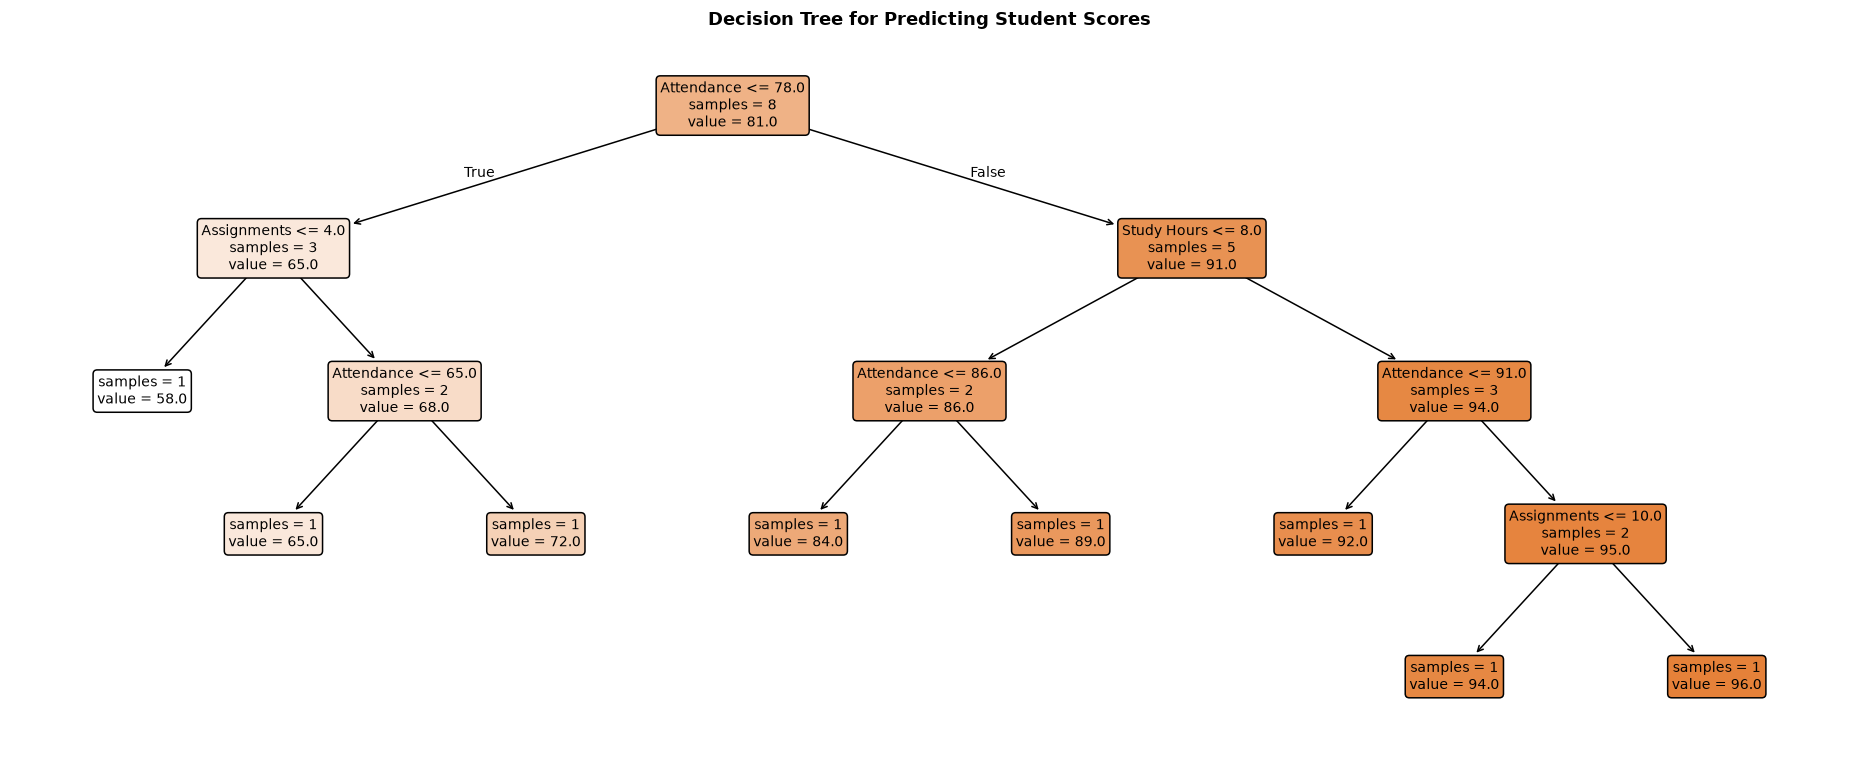

In [54]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

# Create our own data
data = {
    "Name": ["Kenzy", "Menna", "Sama", "Mariam", "Eman", "Jana", "shahd", "Nada"],
    "Study Hours": [8, 6, 3, 9, 4, 7, 2, 8],
    "Attendance": [90, 85, 60, 95, 70, 88, 55, 92],
    "Assignments": [9, 8, 5, 10, 6, 9, 4, 9],
    "Score": [92, 84, 65, 96, 72, 89, 58, 94]
}

df = pd.DataFrame(data)

# Select the features
features = ["Study Hours", "Attendance", "Assignments"]

X = df[features]
y = df["Score"]

# Create the Decision Tree
tree = DecisionTreeRegressor(
    max_depth=8,
    min_samples_leaf=1,
    random_state=42
)

# Train the model
tree.fit(X, y)

# Draw the Decision Tree
plt.figure(figsize=(17, 7))

plot_tree(
    tree,
    feature_names=features,
    filled=True,
    rounded=True,
    fontsize=9,
    precision=0,
    impurity=False
)

plt.title("Decision Tree for Predicting Student Scores")
plt.tight_layout()
plt.show()

In [46]:
from sklearn.ensemble import RandomForestRegressor

model_9 = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,        # grow 300 trees
        max_features=0.4,        # each split may consider 40% of features
        min_samples_leaf=2,      # a leaf must hold >=2 houses (also halves the file size)
        random_state=42,
        n_jobs=-1,               # use all CPU cores
    )),
])
model_9.fit(X_train, y_train)
y_pred_9 = model_9.predict(X_test)

score_model("9. Random Forest (300 trees)", y_test, y_pred_9, "Bagged ensemble", "09_random_forest")

9. Random Forest (300 trees) MAE $  14,217   RMSE $  22,342   R² 0.930


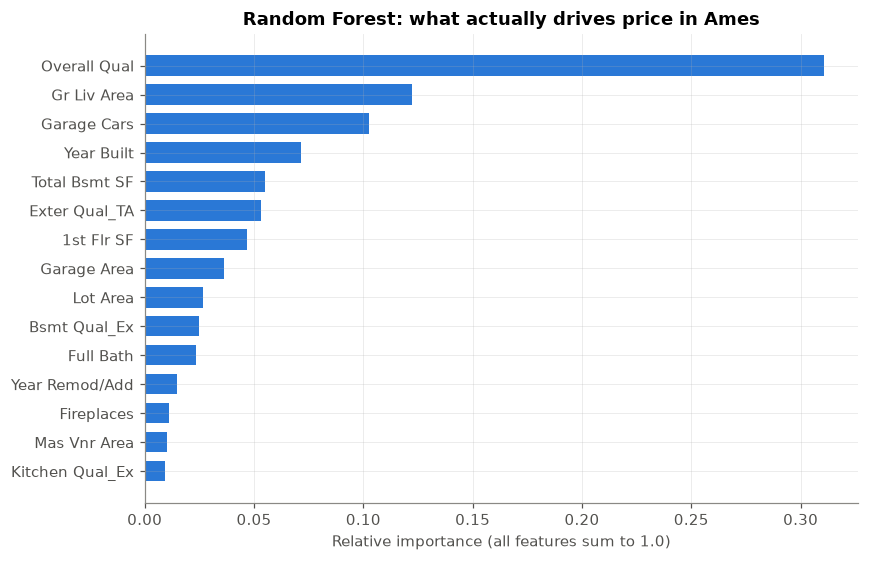

Top 5 features account for 66% of the model's decisions


In [47]:
# Which features does the forest actually rely on?
rf_names = model_9.named_steps["prep"].get_feature_names_out()
importances = pd.Series(model_9.named_steps["model"].feature_importances_, index=rf_names)
top15 = importances.sort_values(ascending=False)[:15][::-1]

plt.figure(figsize=(8, 5.2))
plt.barh(range(len(top15)), top15.values, color=BLUE, height=0.7)
plt.yticks(range(len(top15)), [n.split("__")[-1] for n in top15.index])
plt.xlabel("Relative importance (all features sum to 1.0)")
plt.title("Random Forest: what actually drives price in Ames")
plt.tight_layout(); plt.show()

print(f"Top 5 features account for {top15.values[-5:].sum():.0%} of the model's decisions")

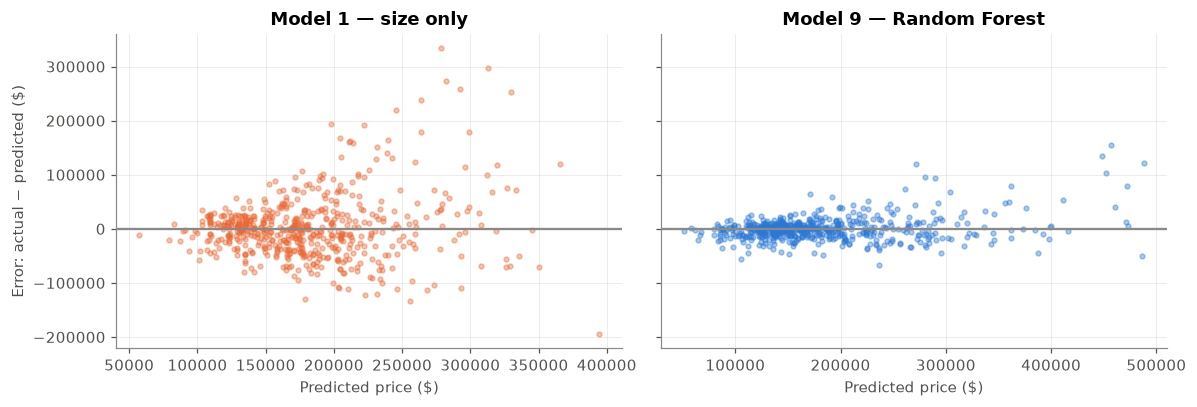

In [48]:
# Did the forest fix the pattern we saw in Model 1's residuals?
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, (pred, name, col) in zip(axes, [(y_pred, "Model 1 — size only", ORANGE),
                                        (y_pred_9, "Model 9 — Random Forest", BLUE)]):
    ax.scatter(pred, y_test - pred, s=10, alpha=0.4, color=col)
    ax.axhline(0, color="#8a8985", linewidth=1.5)
    ax.set_xlabel("Predicted price ($)"); ax.set_title(name)
axes[0].set_ylabel("Error: actual − predicted ($)")
plt.tight_layout(); plt.show()

In [49]:
leaderboard = pd.DataFrame(results).sort_values("MAE ($)").reset_index(drop=True)
display_board = leaderboard.drop(columns=["key"]).copy()
display_board["MAE ($)"]  = display_board["MAE ($)"].map("${:,.0f}".format)
display_board["RMSE ($)"] = display_board["RMSE ($)"].map("${:,.0f}".format)
display_board["R²"]       = display_board["R²"].map("{:.3f}".format)
display_board

,Model,MAE ($),RMSE ($),R²,Note
0,4. Ridge (L2),"$13,829","$22,230",0.930,Polynomial + shrinkage
1,5. Lasso (L1),"$13,905","$21,661",0.934,Kept 83/245 features
2,6. Elastic Net (L1+L2),"$13,905","$21,661",0.934,l1_ratio=1.0
3,9. Random Forest (300 trees),"$14,217","$22,342",0.930,Bagged ensemble
4,3. Polynomial (degree 2),"$14,422","$24,002",0.919,Squares & interactions
5,2. Multiple Linear (27 feat),"$15,392","$23,701",0.921,All features
6,7. SVR (RBF kernel),"$15,396","$22,674",0.928,"C=10, epsilon=0.1"
7,8. Decision Tree (pruned),"$19,285","$28,036",0.889,depth=10
8,1. Simple Linear (1 feature),"$39,604","$58,520",0.518,Size only


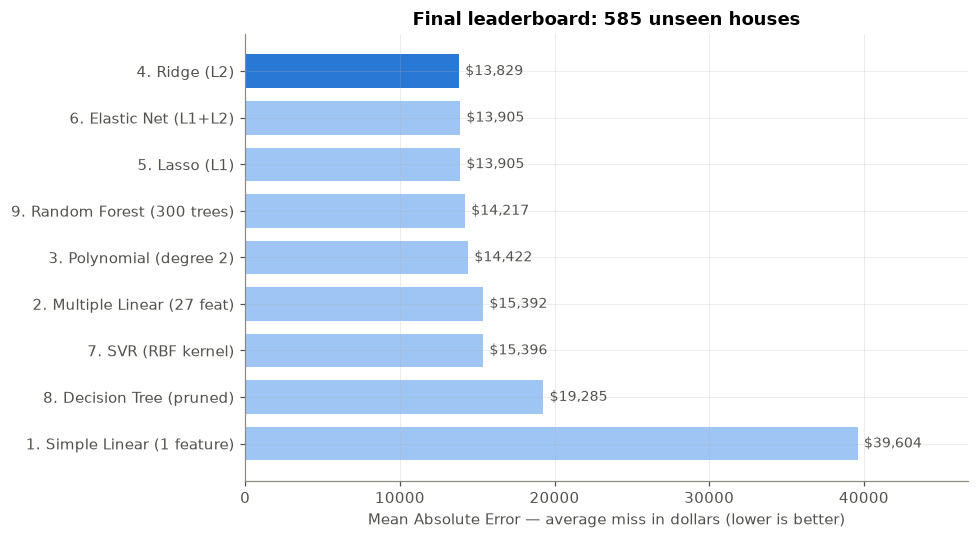

In [50]:
board = leaderboard.sort_values("MAE ($)", ascending=False)
plt.figure(figsize=(9, 5))
bars = plt.barh(range(len(board)), board["MAE ($)"],
                color=[BLUE if i == len(board) - 1 else "#9ec5f4" for i in range(len(board))],
                height=0.72)
plt.yticks(range(len(board)), board["Model"])
for i, v in enumerate(board["MAE ($)"]):
    plt.text(v + 400, i, f"${v:,.0f}", va="center", fontsize=9, color="#52514e")
plt.xlabel("Mean Absolute Error — average miss in dollars (lower is better)")
plt.title("Final leaderboard: 585 unseen houses")
plt.xlim(0, board["MAE ($)"].max() * 1.18)
plt.tight_layout(); plt.show()

In [51]:
import joblib, os

os.makedirs("models", exist_ok=True)

trained = {
    "01_simple_linear":   model_1,
    "02_multiple_linear": model_2,
    "03_polynomial":      model_3,
    "04_ridge":           model_4,
    "05_lasso":           model_5,
    "06_elastic_net":     model_6,
    "07_svr":             model_7,
    "08_decision_tree":   model_8,
    "09_random_forest":   model_9,
}

for name, m in trained.items():
    joblib.dump(m, f"models/{name}.joblib", compress=3)   # compress=3 keeps the repo small
    size_kb = os.path.getsize(f"models/{name}.joblib") / 1024
    print(f"saved  models/{name}.joblib   ({size_kb:>8,.0f} KB)")

saved  models/01_simple_linear.joblib   (       1 KB)
saved  models/02_multiple_linear.joblib   (       4 KB)
saved  models/03_polynomial.joblib   (      10 KB)
saved  models/04_ridge.joblib   (       9 KB)
saved  models/05_lasso.joblib   (      10 KB)
saved  models/06_elastic_net.joblib   (      24 KB)
saved  models/07_svr.joblib   (     158 KB)
saved  models/08_decision_tree.joblib   (       8 KB)
saved  models/09_random_forest.joblib   (   7,732 KB)


In [52]:
# Reload the winning model from disk, as a fresh program would, and price a house
# that appears nowhere in the dataset.
best_key  = leaderboard.iloc[0]["key"]
best_name = leaderboard.iloc[0]["Model"]
best_mae  = leaderboard.iloc[0]["MAE ($)"]
loaded = joblib.load(f"models/{best_key}.joblib")
print(f"Loaded the leaderboard winner: {best_name}\n")

new_house = pd.DataFrame([{
    "Gr Liv Area": 1800, "Total Bsmt SF": 900, "1st Flr SF": 1000, "Lot Area": 9000,
    "Overall Qual": 7, "Overall Cond": 5, "Year Built": 2001, "Year Remod/Add": 2001,
    "Garage Cars": 2, "Garage Area": 500, "Full Bath": 2, "Half Bath": 1,
    "TotRms AbvGrd": 7, "Fireplaces": 1, "Mas Vnr Area": 120,
    "Wood Deck SF": 150, "Open Porch SF": 40,
    "Neighborhood": "CollgCr", "House Style": "2Story", "Bldg Type": "1Fam",
    "Exter Qual": "Gd", "Kitchen Qual": "Gd", "Bsmt Qual": "Gd",
    "Heating QC": "Ex", "Central Air": "Y", "Foundation": "PConc",
    "Garage Type": "Attchd",
}])

estimate = loaded.predict(new_house)[0]
print(f"Estimated sale price:         ${estimate:,.0f}")
print(f"Typical error for this model: ± ${best_mae:,.0f}")

Loaded the leaderboard winner: 4. Ridge (L2)

Estimated sale price:         $210,612
Typical error for this model: ± $13,829


In [53]:
# Wrap it in a function, so the model becomes a tool anyone can use.
def price_a_house(model=None, **facts):
    """Price a house. Any fact you don't give is filled with the Ames median/most common."""
    if model is None:
        model = loaded                     # the leaderboard winner, loaded above
    row = {}
    for c in numeric_features:
        row[c] = houses[c].median()
    for c in categorical_features:
        row[c] = houses[c].mode()[0]
    row.update(facts)                       # your facts override the defaults
    return float(model.predict(pd.DataFrame([row]))[0])

for qual in [4, 6, 8, 10]:
    p = price_a_house(**{"Overall Qual": qual, "Gr Liv Area": 2000})
    print(f"2,000 sq ft, quality {qual:>2}  ->  ${p:>9,.0f}")

2,000 sq ft, quality  4  ->  $  164,589
2,000 sq ft, quality  6  ->  $  188,111
2,000 sq ft, quality  8  ->  $  213,898
2,000 sq ft, quality 10  ->  $  241,950
